# Gujarat Hourly Demand Forecasting with XGBoost

This notebook builds an end-to-end machine learning pipeline for the cleaned Gujarat-only hourly dataset. It uses XGBoost with Bayesian hyperparameter optimization, reduced lag dependence, and time-based evaluation to forecast `demand_mw`.

## Goals and Design

The pipeline is designed to:
- keep the model strictly time-aware
- reduce reliance on lag recursion by using a compact lag set
- use Bayesian hyperparameter search to tune XGBoost
- target `R^2 > 0.8` and peak `MAPE < 5%` on the held-out baseline test period

Split policy for baseline modeling in this notebook:
- Baseline horizon used for train/validation/test: 2020-01-01 to 2024-06-30
- Train: first 70% of baseline horizon
- Validation: next 15% of baseline horizon
- Test: final 15% of baseline horizon

Walk-forward reserved period (not used in baseline split):
- 2024-07-01 to 2025-06-30

Peak demand is evaluated on the top 10% of actual demand values in the corresponding evaluation period.

In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [3]:
candidate_paths = [
    Path('guarat_hourly_demand.csv'),
    Path('gujarat_hourly_merged.csv'),
    Path.cwd() / 'guarat_hourly_demand.csv',
    Path.cwd() / 'gujarat_hourly_merged.csv',
    Path('/media/dhruv/New Volume/project course/guarat_hourly_demand.csv'),
    Path('/media/dhruv/New Volume/project course/gujarat_hourly_merged.csv'),
    Path(r'd:\\project course\\guarat_hourly_demand.csv'),
    Path(r'd:\\project course\\gujarat_hourly_merged.csv'),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        'Could not locate guarat_hourly_demand.csv or gujarat_hourly_merged.csv. Checked: ' + ', '.join(str(p) for p in candidate_paths)
    )

df = pd.read_csv(csv_path)
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.sort_values('datetime').reset_index(drop=True)

print(f'Loaded: {csv_path}')
print(f'Rows, columns: {df.shape}')
print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
print('Year counts:', df['year'].value_counts().sort_index().to_dict())
print('Duplicate datetime rows:', df.duplicated(subset=['datetime']).sum())
print('Duplicate datetime+demand rows:', df.duplicated(subset=['datetime', 'demand_mw']).sum())
df.head()

Loaded: guarat_hourly_demand.csv
Rows, columns: (48191, 35)
Date range: 2020-01-01 01:00:00 to 2025-06-30 23:00:00
Year counts: {2020: 8783, 2021: 8760, 2022: 8760, 2023: 8760, 2024: 8784, 2025: 4344}
Duplicate datetime rows: 0
Duplicate datetime+demand rows: 0


,datetime,demand_mw,year,weather_temperature_2m,weather_shortwave_radiation,weather_windspeed_10m,weather_dewpoint_2m,weather_cloudcover,weather_apparent_temperature,weather_relative_humidity_2m,weather_precipitation,hour,day_of_week,day_of_year,month,is_weekend,is_sunday,year_index,sin_hour,cos_hour,sin_month,cos_month,sin_day_year,cos_day_year,is_peak_season,lag_1h,lag_2h,lag_24h,lag_168h,rolling_mean_6h,rolling_std_6h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h
0,2020-01-01 01:00:00,11382.46,2020,14.22,0.0,10.18,8.06,3.6,12.34,67.0,0.0,1,2,1,1,0,0,0,0.258819,0.965926,0.5,0.866025,0.017202,0.999852,0,11422.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 02:00:00,11286.84,2020,14.00,0.0,10.70,7.96,9.0,12.06,67.0,0.0,2,2,1,1,0,0,0,0.500000,0.866025,0.5,0.866025,0.017202,0.999852,0,11382.46,11422.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 03:00:00,11134.70,2020,13.84,0.0,10.98,7.94,23.2,11.88,68.0,0.0,3,2,1,1,0,0,0,0.707107,0.707107,0.5,0.866025,0.017202,0.999852,0,11286.84,11382.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 04:00:00,10973.96,2020,13.80,0.0,11.30,7.98,24.6,11.72,68.6,0.0,4,2,1,1,0,0,0,0.866025,0.500000,0.5,0.866025,0.017202,0.999852,0,11134.70,11286.84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 05:00:00,11396.30,2020,13.22,0.0,11.28,8.12,28.2,11.18,71.6,0.0,5,2,1,1,0,0,0,0.965926,0.258819,0.5,0.866025,0.017202,0.999852,0,10973.96,11134.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
def add_extra_features(frame):
    data = frame.copy()
    data = data.sort_values('datetime').reset_index(drop=True)

    # Backward-compatible fallbacks if the expanded weather columns are not yet present.
    if 'weather_relative_humidity_2m' not in data.columns:
        temp = data['weather_temperature_2m']
        dewpoint = data['weather_dewpoint_2m']
        saturation_vp = 6.112 * np.exp((17.67 * temp) / (temp + 243.5))
        actual_vp = 6.112 * np.exp((17.67 * dewpoint) / (dewpoint + 243.5))
        data['weather_relative_humidity_2m'] = np.clip((actual_vp / saturation_vp) * 100.0, 0.0, 100.0)
    if 'weather_precipitation' not in data.columns:
        data['weather_precipitation'] = 0.0

    # Existing interactions
    data['temp_x_peak'] = data['weather_temperature_2m'] * data['is_peak_season']
    data['solar_x_peak'] = data['weather_shortwave_radiation'] * data['is_peak_season']
    data['temp_x_hour_sin'] = data['weather_temperature_2m'] * data['sin_hour']
    data['lag_momentum_1_24'] = data['lag_1h'] - data['lag_24h']
    data['lag_momentum_24_168'] = data['lag_24h'] - data['lag_168h']
    data['weather_balance'] = data['weather_temperature_2m'] - data['weather_dewpoint_2m']

    # New weather features from expanded station-based dataset
    data['temp_x_humidity'] = data['weather_temperature_2m'] * data['weather_relative_humidity_2m']
    data['rain_flag'] = (data['weather_precipitation'] > 0).astype(int)
    data['precip_x_peak'] = data['weather_precipitation'] * data['is_peak_season']
    data['cloud_x_temp'] = data['weather_cloudcover'] * data['weather_temperature_2m']

    # Degree-day style nonlinearity for thermal demand response
    data['cdd_24'] = np.clip(data['weather_temperature_2m'] - 24.0, 0.0, None)
    data['hdd_18'] = np.clip(18.0 - data['weather_temperature_2m'], 0.0, None)
    data['apparent_minus_temp'] = data['weather_apparent_temperature'] - data['weather_temperature_2m']
    data['rad_x_temp'] = data['weather_shortwave_radiation'] * data['weather_temperature_2m']

    # Additional demand memory from past observations only
    shifted = data['demand_mw'].shift(1)
    data['lag_48h'] = data['demand_mw'].shift(48)
    data['lag_336h'] = data['demand_mw'].shift(336)
    data['rolling_mean_6h_from_target'] = shifted.rolling(6, min_periods=6).mean()
    data['rolling_max_24h_from_target'] = shifted.rolling(24, min_periods=24).max()
    data['ewm_24h_from_target'] = shifted.ewm(span=24, adjust=False).mean()

    temp_q75 = data['weather_temperature_2m'].quantile(0.75)
    data['hot_flag'] = (data['weather_temperature_2m'] >= temp_q75).astype(int)
    data['hot_hour_interaction'] = data['hot_flag'] * data['hour']

    return data

df = add_extra_features(df)

feature_cols = [
    'weather_temperature_2m',
    'weather_relative_humidity_2m',
    'weather_shortwave_radiation',
    'weather_precipitation',
    'weather_windspeed_10m',
    'weather_dewpoint_2m',
    'weather_cloudcover',
    'weather_apparent_temperature',
    'hour',
    'day_of_week',
    'day_of_year',
    'month',
    'is_weekend',
    'is_sunday',
    'year_index',
    'sin_hour',
    'cos_hour',
    'sin_month',
    'cos_month',
    'sin_day_year',
    'cos_day_year',
    'is_peak_season',
    'lag_1h',
    'lag_24h',
    'lag_168h',
    'lag_48h',
    'lag_336h',
    'rolling_mean_24h',
    'rolling_std_24h',
    'rolling_mean_168h',
    'rolling_std_168h',
    'rolling_mean_6h_from_target',
    'rolling_max_24h_from_target',
    'ewm_24h_from_target',
    'temp_x_peak',
    'solar_x_peak',
    'temp_x_hour_sin',
    'lag_momentum_1_24',
    'lag_momentum_24_168',
    'weather_balance',
    'temp_x_humidity',
    'rain_flag',
    'precip_x_peak',
    'cloud_x_temp',
    'cdd_24',
    'hdd_18',
    'apparent_minus_temp',
    'rad_x_temp',
    'hot_flag',
    'hot_hour_interaction',
]
feature_cols = [col for col in feature_cols if col in df.columns]
target_col = 'demand_mw'

missing_check = df[feature_cols + [target_col]].isna().sum().sort_values(ascending=False)
print('Missing values in model features:')
print(missing_check[missing_check > 0].to_string())

df_model = df.dropna(subset=feature_cols + [target_col]).copy()
print(f'Modeling rows after dropna: {len(df_model)}')
print('Years present:', sorted(df_model['year'].unique().tolist()))

Missing values in model features:
lag_336h                       336
lag_168h                       167
rolling_mean_168h              167
rolling_std_168h               167
lag_momentum_24_168            167
lag_48h                         48
rolling_max_24h_from_target     24
rolling_std_24h                 23
lag_momentum_1_24               23
lag_24h                         23
rolling_mean_24h                23
rolling_mean_6h_from_target      6
ewm_24h_from_target              1
Modeling rows after dropna: 47855
Years present: [2020, 2021, 2022, 2023, 2024, 2025]


## Train / Validation / Test Split (Baseline Horizon for Walk-Forward)

This notebook now follows the benchmark setup:
- Baseline modeling horizon: **2020-01-01 to 2024-06-30**
- Walk-forward holdout horizon: **2024-07-01 to 2025-06-30**

Inside the baseline horizon, we keep strict chronology and split as:
- Train: first 70%
- Validation: next 15%
- Test: final 15%

This keeps ordering intact, avoids leakage, and aligns the notebook with the planned walk-forward evaluation period.

In [5]:
from sklearn.model_selection import TimeSeriesSplit

# Baseline model horizon (train/val/test happens only inside this window).
BASELINE_START = pd.Timestamp('2020-01-01 00:00:00')
BASELINE_END = pd.Timestamp('2024-06-30 23:59:59')

# Reserved for walk-forward benchmarking (not used in baseline split).
WALK_FORWARD_START = pd.Timestamp('2024-07-01 00:00:00')
WALK_FORWARD_END = pd.Timestamp('2025-06-30 23:59:59')

train_pct, val_pct, test_pct = 0.70, 0.15, 0.15
PEAK_WEIGHT = 60.0

chron_df = df_model.sort_values('datetime').copy()
split_df = chron_df[(chron_df['datetime'] >= BASELINE_START) & (chron_df['datetime'] <= BASELINE_END)].copy()
walk_forward_df = chron_df[(chron_df['datetime'] >= WALK_FORWARD_START) & (chron_df['datetime'] <= WALK_FORWARD_END)].copy()

if split_df.empty:
    raise ValueError('No rows found in baseline horizon 2020-01-01 to 2024-06-30. Regenerate dataset first.')

n_total = len(split_df)
test_size = int(n_total * test_pct)

# 1) Split off test set from the tail of baseline horizon.
tscv_test = TimeSeriesSplit(n_splits=2, test_size=test_size)
trainval_idx, test_idx = list(tscv_test.split(split_df))[-1]

trainval_df = split_df.iloc[trainval_idx].copy()
test_df = split_df.iloc[test_idx].copy()

# 2) Split train/val from baseline head.
val_size = int(len(trainval_df) * (val_pct / (train_pct + val_pct)))
tscv_val = TimeSeriesSplit(n_splits=2, test_size=val_size)
train_idx, val_idx = list(tscv_val.split(trainval_df))[-1]

train_df = trainval_df.iloc[train_idx].copy()
val_df = trainval_df.iloc[val_idx].copy()

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_val = val_df[feature_cols]
y_val = val_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Combined pre-test set for rolling-fold Bayesian tuning.
tune_df = pd.concat([train_df, val_df], axis=0).sort_values('datetime').reset_index(drop=True)
X_tune = tune_df[feature_cols]
y_tune = tune_df[target_col]
tscv_tune = TimeSeriesSplit(n_splits=6)

peak_threshold_train = y_train.quantile(0.9)
peak_threshold_test = y_test.quantile(0.9)
train_weights = np.where(y_train >= peak_threshold_train, PEAK_WEIGHT, 1.0)
val_weights = np.where(y_val >= y_val.quantile(0.9), PEAK_WEIGHT, 1.0)

print('Baseline horizon:', split_df['datetime'].min(), 'to', split_df['datetime'].max())
print('Walk-forward reserved horizon:', walk_forward_df['datetime'].min(), 'to', walk_forward_df['datetime'].max())
print('Rows reserved for walk-forward:', len(walk_forward_df))
print('Split sizes (baseline horizon only):')
print(f'  Train: {len(train_df)}')
print(f'  Val  : {len(val_df)}')
print(f'  Test : {len(test_df)}')
print(f'  Tune (Train+Val): {len(tune_df)}')
print('Peak threshold (train 90th pct):', round(float(peak_threshold_train), 2))
print('Peak threshold (test 90th pct):', round(float(peak_threshold_test), 2))
print('Peak sample weight:', PEAK_WEIGHT)
print('Target scale check (original):')
print('  train min/max:', round(float(y_train.min()), 2), round(float(y_train.max()), 2))
print('  val min/max  :', round(float(y_val.min()), 2), round(float(y_val.max()), 2))
print('  test min/max :', round(float(y_test.min()), 2), round(float(y_test.max()), 2))

Baseline horizon: 2020-01-15 01:00:00 to 2024-06-30 23:00:00
Walk-forward reserved horizon: 2024-07-01 00:00:00 to 2025-06-30 23:00:00
Rows reserved for walk-forward: 8760
Split sizes (baseline horizon only):
  Train: 27367
  Val  : 5864
  Test : 5864
  Tune (Train+Val): 33231
Peak threshold (train 90th pct): 17654.35
Peak threshold (test 90th pct): 20917.51
Peak sample weight: 60.0
Target scale check (original):
  train min/max: 5685.85 21202.14
  val min/max  : 10700.87 24183.89
  test min/max : 9076.07 26054.0


In [6]:
def regression_report(y_true, y_pred, peak_threshold=None):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-9, None))) * 100)
    report = {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape}
    if peak_threshold is not None:
        peak_mask = y_true >= peak_threshold
        peak_mape = float(np.mean(np.abs((y_true[peak_mask] - y_pred[peak_mask]) / np.clip(y_true[peak_mask], 1e-9, None))) * 100)
        report['Peak_MAPE_%'] = peak_mape
        report['Peak_Count'] = int(peak_mask.sum())
    return report

# Simple baselines to show improvement over persistence-style forecasts.
baseline_1h = test_df['lag_1h'].to_numpy()
baseline_24h = test_df['lag_24h'].to_numpy()
baseline_168h = test_df['lag_168h'].to_numpy()

baseline_reports = {
    'lag_1h': regression_report(y_test.to_numpy(), baseline_1h, peak_threshold_test),
    'lag_24h': regression_report(y_test.to_numpy(), baseline_24h, peak_threshold_test),
    'lag_168h': regression_report(y_test.to_numpy(), baseline_168h, peak_threshold_test),
}
pd.DataFrame(baseline_reports).T

,R2,MAE,RMSE,MAPE_%,Peak_MAPE_%,Peak_Count
lag_1h,0.921903,583.465109,757.072852,3.265097,3.628600,587.0
lag_24h,0.822014,703.820186,1142.915082,4.197434,3.083565,587.0
lag_168h,0.503870,1224.221869,1908.177981,7.540752,4.780549,587.0


## Bayesian Optimization with TimeSeriesSplit

We tune XGBoost with Bayesian optimization using rolling `TimeSeriesSplit` folds on the pre-test data. This makes hyperparameter selection robust to temporal drift and avoids leakage from future observations. The objective is mean RMSE across folds.

In [7]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 1500, 6000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'subsample': trial.suggest_float('subsample', 0.75, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 6.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 100.0, log=True),
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1,
        'early_stopping_rounds': 150,
        'eval_metric': 'rmse',
    }

    fold_scores = []
    fold_rmses = []
    fold_peak_mapes = []
    fold_best_iterations = []

    for tr_idx, va_idx in tscv_tune.split(X_tune):
        X_tr = X_tune.iloc[tr_idx]
        y_tr = y_tune.iloc[tr_idx]
        X_va = X_tune.iloc[va_idx]
        y_va = y_tune.iloc[va_idx]

        w_tr = np.where(y_tr >= y_tr.quantile(0.9), PEAK_WEIGHT, 1.0)

        model = XGBRegressor(**params)
        model.fit(
            X_tr,
            np.log1p(y_tr),
            sample_weight=w_tr,
            eval_set=[(X_va, np.log1p(y_va))],
            verbose=False,
        )

        best_iter = int(getattr(model, 'best_iteration', params['n_estimators'] - 1))
        preds = np.expm1(model.predict(X_va, iteration_range=(0, best_iter + 1)))

        rmse = float(np.sqrt(mean_squared_error(y_va, preds)))
        nrmse_pct = float((rmse / np.clip(np.mean(y_va), 1e-9, None)) * 100.0)
        peak_mask = y_va >= y_va.quantile(0.9)
        peak_mape = float(
            np.mean(
                np.abs((y_va[peak_mask] - preds[peak_mask]) / np.clip(y_va[peak_mask], 1e-9, None))
            ) * 100
        )

        # Favor overall fit while still prioritizing peak-hour behavior.
        blended_score = 0.65 * nrmse_pct + 0.35 * peak_mape

        fold_scores.append(blended_score)
        fold_rmses.append(rmse)
        fold_peak_mapes.append(peak_mape)
        fold_best_iterations.append(best_iter + 1)

    trial.set_user_attr('cv_blended_score_mean', float(np.mean(fold_scores)))
    trial.set_user_attr('cv_rmse_mean', float(np.mean(fold_rmses)))
    trial.set_user_attr('cv_peak_mape_mean', float(np.mean(fold_peak_mapes)))
    trial.set_user_attr('best_iteration', int(np.median(fold_best_iterations)))
    return float(np.mean(fold_scores))

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=45, show_progress_bar=False)

print('Best blended CV score (lower is better):', study.best_value)
print('Best params:')
print(study.best_params)
print('Chosen estimator count:', study.best_trial.user_attrs['best_iteration'])
print('CV RMSE mean:', round(study.best_trial.user_attrs['cv_rmse_mean'], 4))
print('CV peak MAPE mean (%):', round(study.best_trial.user_attrs['cv_peak_mape_mean'], 4))

[I 2026-04-19 00:14:41,809] A new study created in memory with name: no-name-ffb0848d-b6d9-41bc-ac77-d0fa7b55e629
[I 2026-04-19 00:14:47,439] Trial 0 finished with value: 3.3293251123461935 and parameters: {'n_estimators': 3185, 'max_depth': 9, 'learning_rate': 0.038052091892039265, 'subsample': 0.8996646210492591, 'colsample_bytree': 0.7046065241548528, 'min_child_weight': 1.4321698289111515, 'gamma': 0.34850167300919677, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 1.0129197956845732}. Best is trial 0 with value: 3.3293251123461935.
[I 2026-04-19 00:14:52,158] Trial 1 finished with value: 3.7853693276195997 and parameters: {'n_estimators': 4687, 'max_depth': 3, 'learning_rate': 0.07359661480116786, 'subsample': 0.9581106602001055, 'colsample_bytree': 0.7243186887373967, 'min_child_weight': 1.5199348301309807, 'gamma': 1.100427059120603, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.4205156450913872}. Best is trial 0 with value: 3.3293251123461935.
[I 2026-04-19 00:14:58,914] 

Best blended CV score (lower is better): 2.6445632954302867
Best params:
{'n_estimators': 2236, 'max_depth': 3, 'learning_rate': 0.009971266591995829, 'subsample': 0.7703840694108496, 'colsample_bytree': 0.9164836761839266, 'min_child_weight': 6.050433545028186, 'gamma': 0.010796395249213307, 'reg_alpha': 5.7792085961704865e-06, 'reg_lambda': 0.01551748992691064}
Chosen estimator count: 2217
CV RMSE mean: 386.6237
CV peak MAPE mean (%): 2.9366


## Final Model Fit and Test Evaluation

The final pipeline uses a two-stage fit:
- Stage 1: calibrate effective tree count with early stopping on train/validation
- Stage 2: retrain on the full pre-test window with calibrated tree count

This approach typically improves generalization versus fixing tree count from a single trial value.

In [8]:
best_params = study.best_params.copy()
best_n_estimators = int(study.best_trial.user_attrs['best_iteration'])

# Stage 1: calibrate iteration count on train->val with early stopping.
calibration_model = XGBRegressor(
    n_estimators=max(best_n_estimators, 1200),
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    min_child_weight=best_params['min_child_weight'],
    gamma=best_params['gamma'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=150,
    eval_metric='rmse',
)

calibration_model.fit(
    X_train,
    np.log1p(y_train),
    sample_weight=train_weights,
    eval_set=[(X_val, np.log1p(y_val))],
    verbose=False,
)

calibrated_trees = int(getattr(calibration_model, 'best_iteration', best_n_estimators - 1)) + 1
print('Calibrated tree count from validation early stopping:', calibrated_trees)

# Stage 2: fit final model on all pre-test data with calibrated tree count.
X_trainval = X_tune
y_trainval = y_tune
trainval_weights = np.where(y_trainval >= y_trainval.quantile(0.9), PEAK_WEIGHT, 1.0)

final_model = XGBRegressor(
    n_estimators=calibrated_trees,
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    min_child_weight=best_params['min_child_weight'],
    gamma=best_params['gamma'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse',
)
final_model.fit(X_trainval, np.log1p(y_trainval), sample_weight=trainval_weights, verbose=False)

train_pred = np.expm1(final_model.predict(X_train))
val_pred = np.expm1(final_model.predict(X_val))
test_pred = np.expm1(final_model.predict(X_test))

train_report = regression_report(y_train.to_numpy(), train_pred, peak_threshold_train)
val_report = regression_report(y_val.to_numpy(), val_pred, y_val.quantile(0.9))
test_report = regression_report(y_test.to_numpy(), test_pred, peak_threshold_test)

results = pd.DataFrame([train_report, val_report, test_report], index=['Train', 'Validation', 'Test'])
print('Scores for all three sets:')
display(results)

Calibrated tree count from validation early stopping: 2023
Scores for all three sets:


,R2,MAE,RMSE,MAPE_%,Peak_MAPE_%,Peak_Count
Train,0.985426,206.051040,277.443396,1.454521,1.061838,2738
Validation,0.977649,215.553235,318.878731,1.288530,0.650736,587
Test,0.970196,345.191570,467.692846,1.953074,2.110533,587


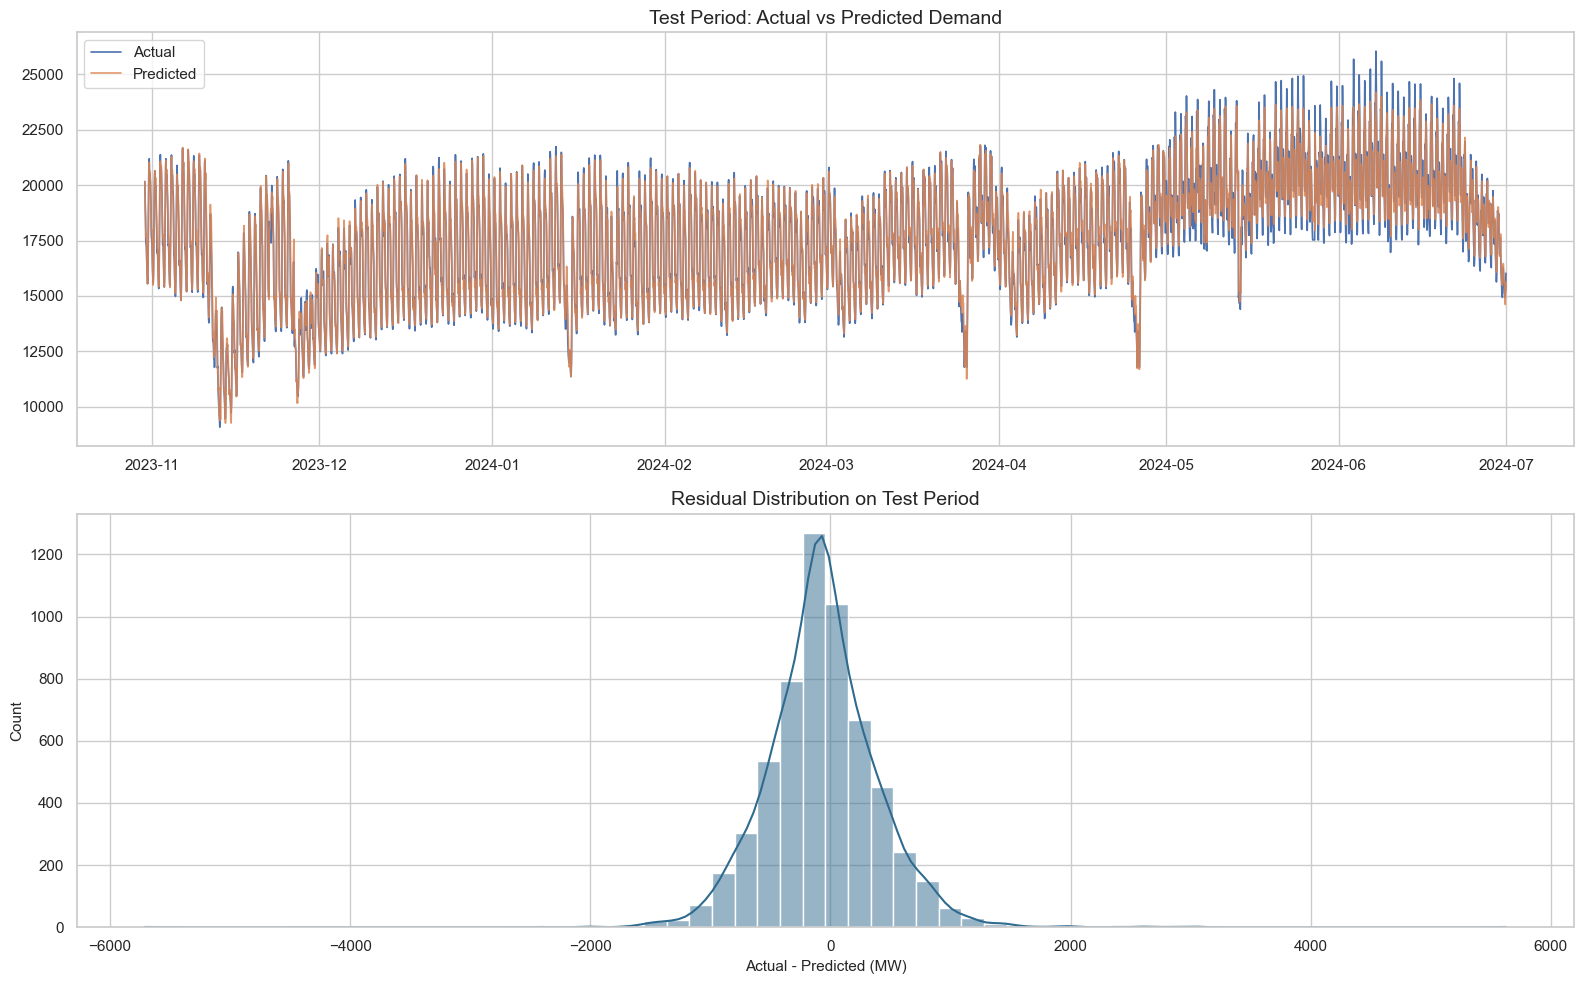

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

sample_test = test_df[['datetime', 'demand_mw']].copy()
sample_test['pred'] = test_pred
sample_test['residual'] = sample_test['demand_mw'] - sample_test['pred']
sample_test = sample_test.sort_values('datetime')

axes[0].plot(sample_test['datetime'], sample_test['demand_mw'], label='Actual', linewidth=1.2)
axes[0].plot(sample_test['datetime'], sample_test['pred'], label='Predicted', linewidth=1.2, alpha=0.85)
axes[0].set_title('Test Period: Actual vs Predicted Demand')
axes[0].legend()

sns.histplot(sample_test['residual'], bins=60, kde=True, ax=axes[1], color='#2f6b8f')
axes[1].set_title('Residual Distribution on Test Period')
axes[1].set_xlabel('Actual - Predicted (MW)')
plt.tight_layout()

,importance
lag_1h,0.492206
rolling_max_24h_from_target,0.195126
lag_24h,0.124556
lag_48h,0.028596
lag_168h,0.022390
rolling_mean_6h_from_target,0.019484
cos_hour,0.012163
rolling_mean_24h,0.011514
sin_hour,0.008322
is_sunday,0.007594


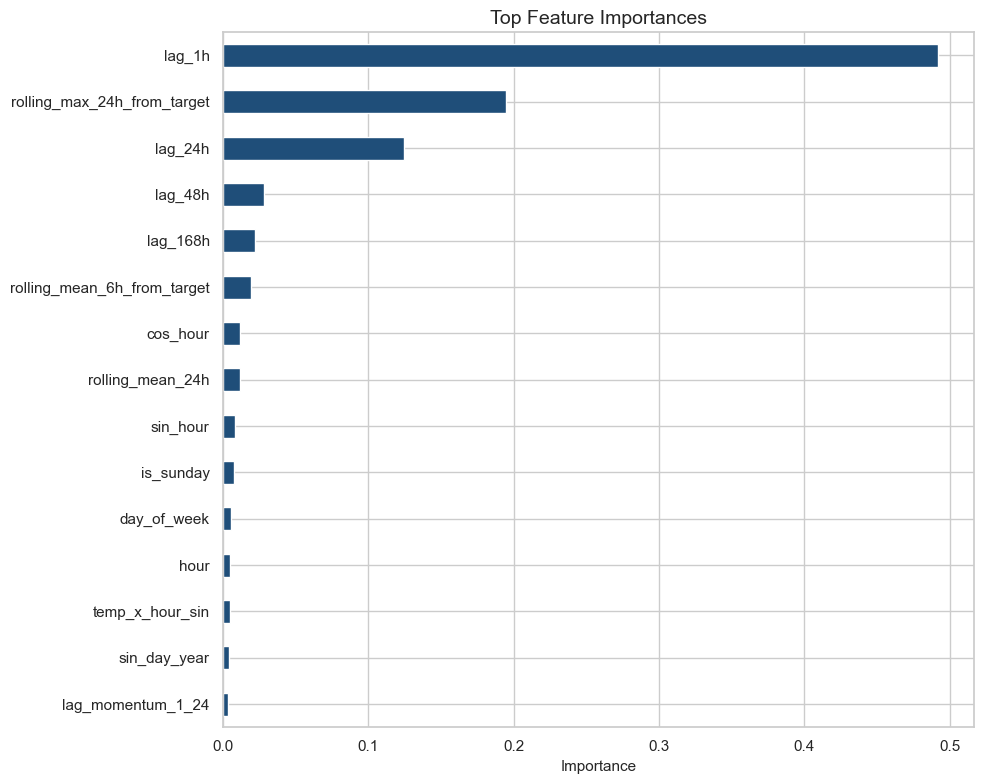

In [10]:
importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importance.head(15).to_frame('importance'))

plt.figure(figsize=(10, 8))
importance.head(15).sort_values().plot(kind='barh', color='#1f4e79')
plt.title('Top Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()

## Decision Rule

If test `R^2` is above 0.8 and peak `MAPE` is below 5%, the model is good enough to proceed. If not, the next steps are to add weather interactions, adjust lag features, or test a stronger tree ensemble / sequence model hybrid.

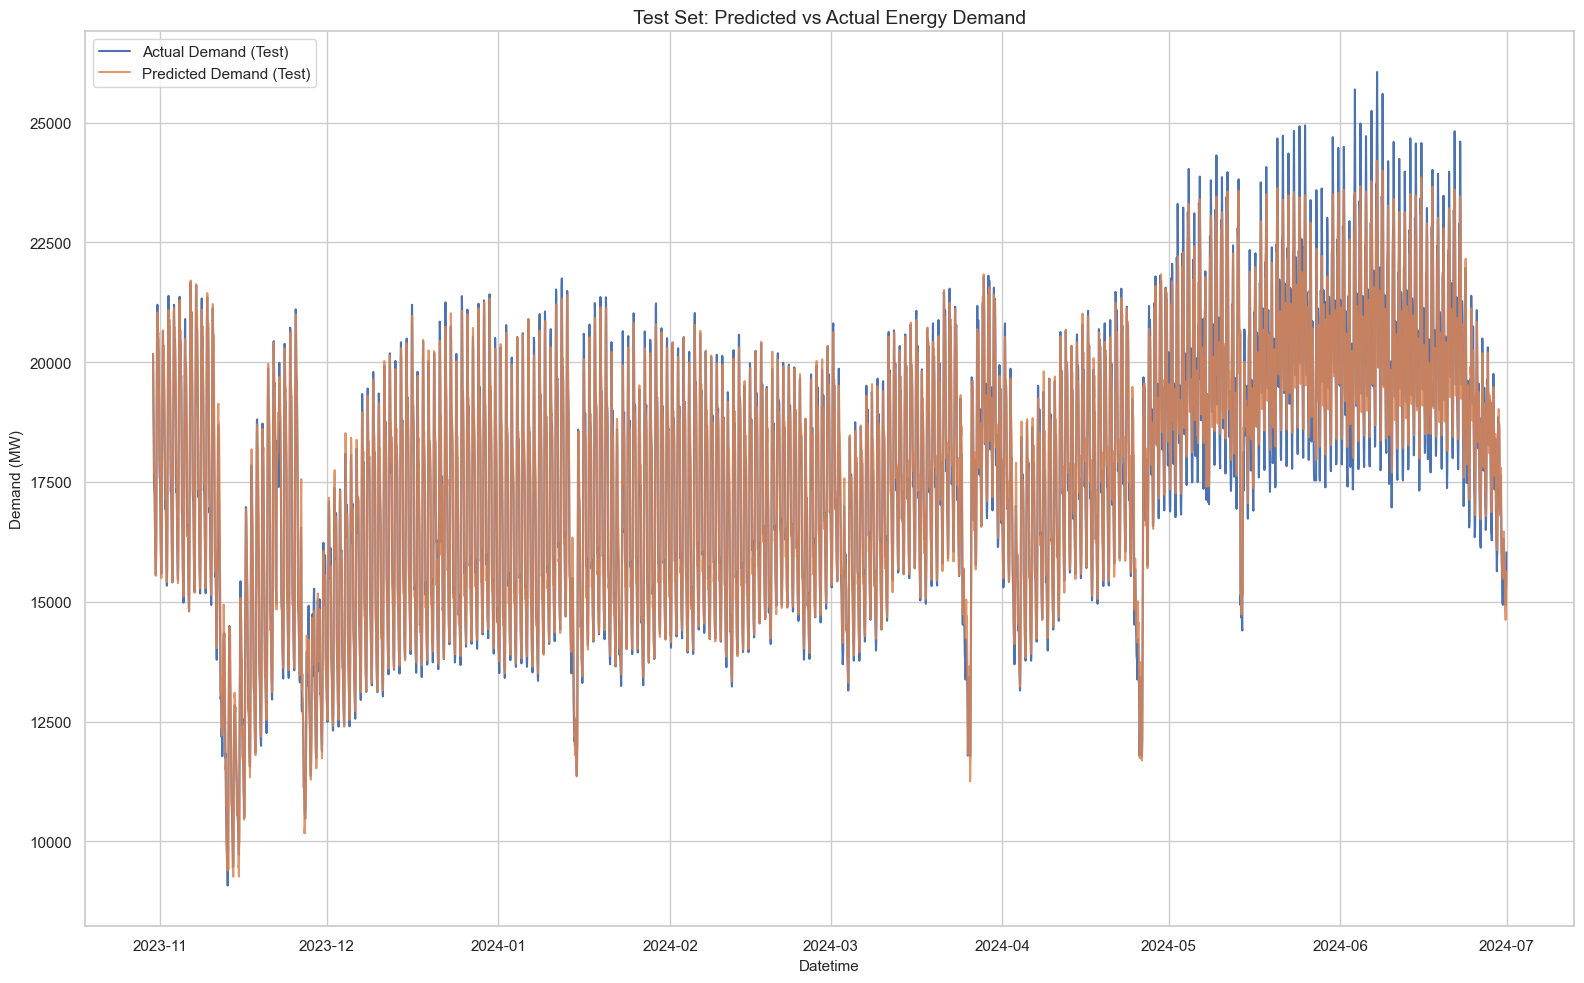

In [11]:
plt.figure(figsize=(16, 10))
plt.plot(sample_test['datetime'], sample_test['demand_mw'], label='Actual Demand (Test)', linewidth=1.5)
plt.plot(sample_test['datetime'], sample_test['pred'], label='Predicted Demand (Test)', linewidth=1.5, alpha=0.85)

plt.title('Test Set: Predicted vs Actual Energy Demand')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def build_pred_actual_table(split_df, y_true, y_pred, name, n_rows=24):
    tbl = pd.DataFrame({
        'datetime': split_df['datetime'].values,
        'actual_mw': y_true.to_numpy(),
        'predicted_mw': y_pred,
    })
    tbl['error_mw'] = tbl['actual_mw'] - tbl['predicted_mw']
    tbl['abs_pct_error'] = (tbl['error_mw'].abs() / np.clip(tbl['actual_mw'], 1e-9, None)) * 100
    print(f'\n{name} prediction vs actual (first {n_rows} rows):')
    display(tbl.head(n_rows))
    return tbl

train_pred_vs_actual = build_pred_actual_table(train_df, y_train, train_pred, 'Train')
val_pred_vs_actual = build_pred_actual_table(val_df, y_val, val_pred, 'Validation')
test_pred_vs_actual = build_pred_actual_table(test_df, y_test, test_pred, 'Test')

print('\nAverage absolute percentage error by split (%):')
print(
    pd.Series({
        'Train': train_pred_vs_actual['abs_pct_error'].mean(),
        'Validation': val_pred_vs_actual['abs_pct_error'].mean(),
        'Test': test_pred_vs_actual['abs_pct_error'].mean(),
    }).round(4).to_string()
 )


Train prediction vs actual (first 24 rows):


,datetime,actual_mw,predicted_mw,error_mw,abs_pct_error
0,2020-01-15 01:00:00,9206.86,9282.120117,-75.260117,0.817435
1,2020-01-15 02:00:00,9143.90,9152.739258,-8.839258,0.096668
2,2020-01-15 03:00:00,9020.78,9240.294922,-219.514922,2.433436
3,2020-01-15 04:00:00,9003.48,8965.541992,37.938008,0.421370
4,2020-01-15 05:00:00,9416.07,9628.094727,-212.024727,2.251733
5,2020-01-15 06:00:00,10259.13,9880.725586,378.404414,3.688465
6,2020-01-15 07:00:00,11631.87,11039.106445,592.763555,5.096030
7,2020-01-15 08:00:00,12527.32,11561.773438,965.546562,7.707527
8,2020-01-15 09:00:00,13152.79,12483.907227,668.882773,5.085482
9,2020-01-15 10:00:00,13269.93,12942.320312,327.609688,2.468812



Validation prediction vs actual (first 24 rows):


,datetime,actual_mw,predicted_mw,error_mw,abs_pct_error
0,2023-02-28 08:00:00,17907.29,18180.724609,-273.434609,1.526946
1,2023-02-28 09:00:00,18493.89,18616.916016,-123.026016,0.665225
2,2023-02-28 10:00:00,18855.05,18872.359375,-17.309375,0.091802
3,2023-02-28 11:00:00,18732.62,18851.277344,-118.657344,0.633426
4,2023-02-28 12:00:00,17998.73,18355.560547,-356.830547,1.982532
5,2023-02-28 13:00:00,17492.92,18058.875000,-565.955000,3.235337
6,2023-02-28 14:00:00,18050.45,18219.259766,-168.809766,0.935211
7,2023-02-28 15:00:00,18335.57,18423.435547,-87.865547,0.479208
8,2023-02-28 16:00:00,18470.62,18396.625000,73.995000,0.400609
9,2023-02-28 17:00:00,18499.45,18372.585938,126.864063,0.685772



Test prediction vs actual (first 24 rows):


,datetime,actual_mw,predicted_mw,error_mw,abs_pct_error
0,2023-10-30 16:00:00,20169.25,20160.449219,8.800781,0.043635
1,2023-10-30 17:00:00,19511.64,19712.839844,-201.199844,1.031179
2,2023-10-30 18:00:00,19031.69,18924.556641,107.133359,0.562921
3,2023-10-30 19:00:00,18517.20,18610.312500,-93.112500,0.502843
4,2023-10-30 20:00:00,17550.61,18054.638672,-504.028672,2.871858
5,2023-10-30 21:00:00,17378.46,17673.929688,-295.469688,1.700206
6,2023-10-30 22:00:00,17313.15,17817.056641,-503.906641,2.910543
7,2023-10-30 23:00:00,17189.71,17420.095703,-230.385703,1.340254
8,2023-10-31 00:00:00,16704.61,16789.605469,-84.995469,0.508814
9,2023-10-31 01:00:00,16312.20,16136.698242,175.501758,1.075893



Average absolute percentage error by split (%):
Train         1.4545
Validation    1.2885
Test          1.9531


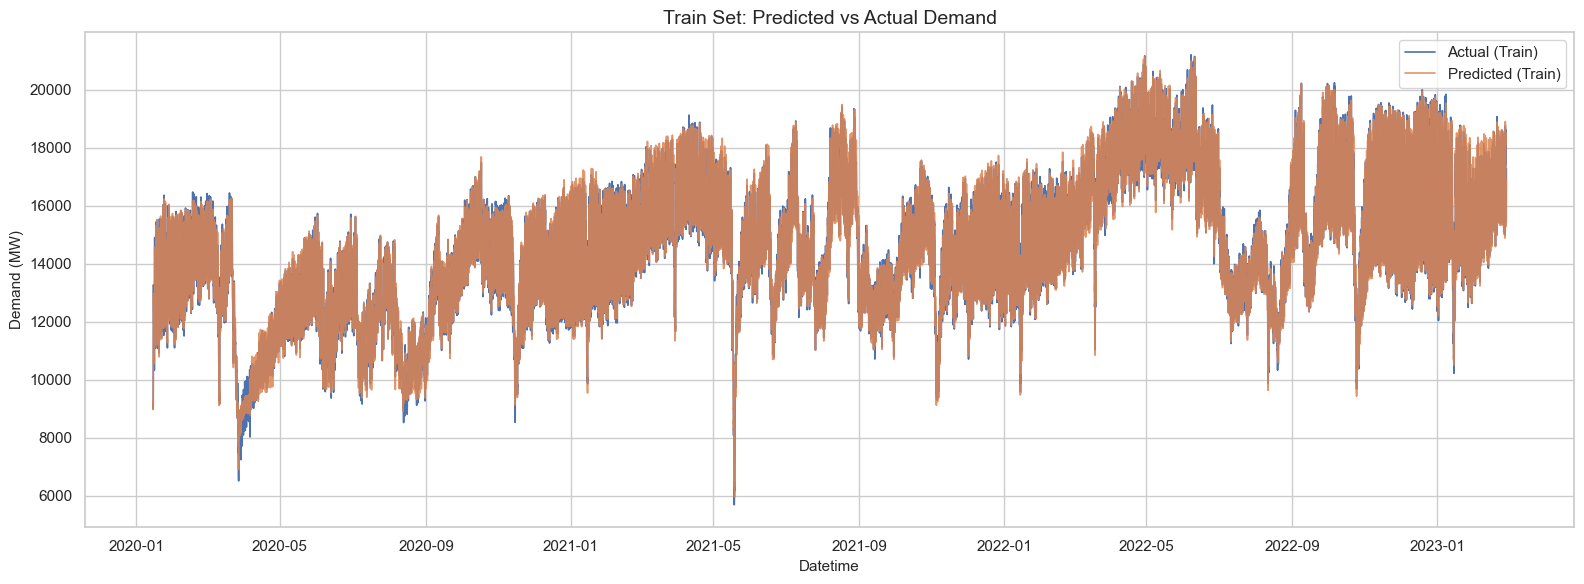

In [13]:
train_plot = train_pred_vs_actual.sort_values('datetime').copy()

plt.figure(figsize=(16, 6))
plt.plot(train_plot['datetime'], train_plot['actual_mw'], label='Actual (Train)', linewidth=1.2)
plt.plot(train_plot['datetime'], train_plot['predicted_mw'], label='Predicted (Train)', linewidth=1.2, alpha=0.85)

plt.title('Train Set: Predicted vs Actual Demand')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

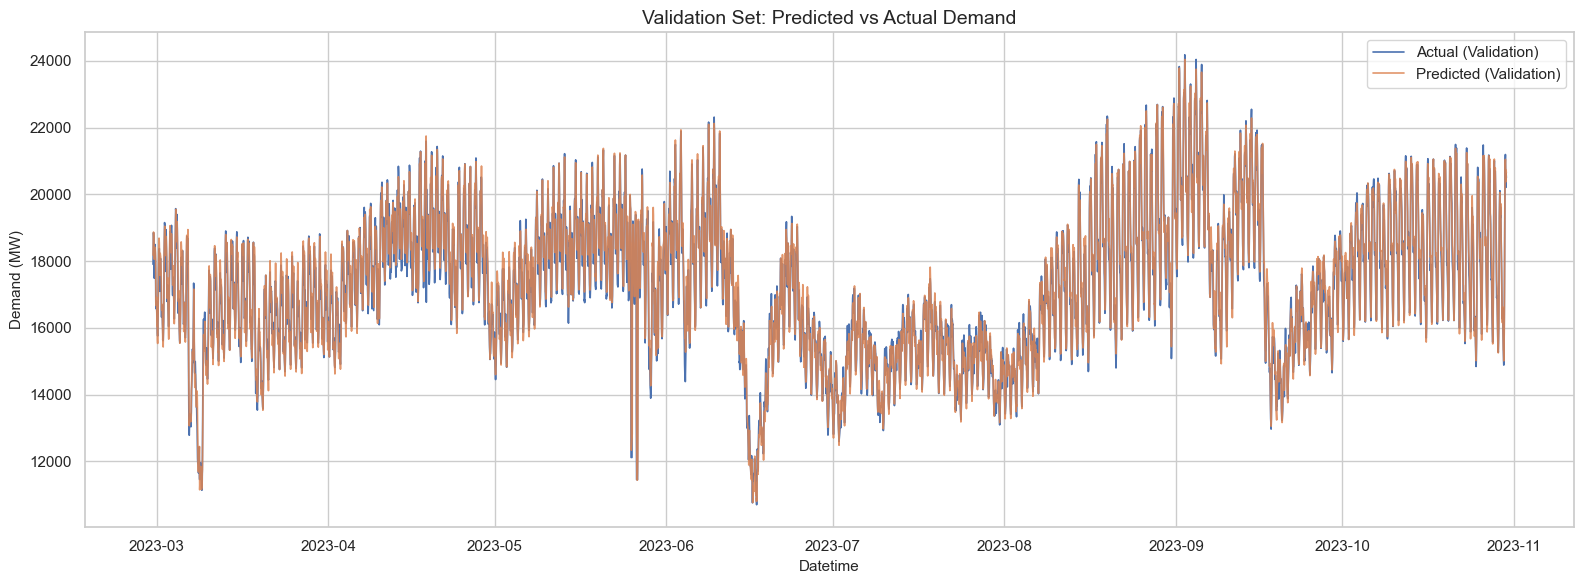

In [14]:
val_plot = val_pred_vs_actual.sort_values('datetime').copy()

plt.figure(figsize=(16, 6))
plt.plot(val_plot['datetime'], val_plot['actual_mw'], label='Actual (Validation)', linewidth=1.2)
plt.plot(val_plot['datetime'], val_plot['predicted_mw'], label='Predicted (Validation)', linewidth=1.2, alpha=0.85)

plt.title('Validation Set: Predicted vs Actual Demand')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

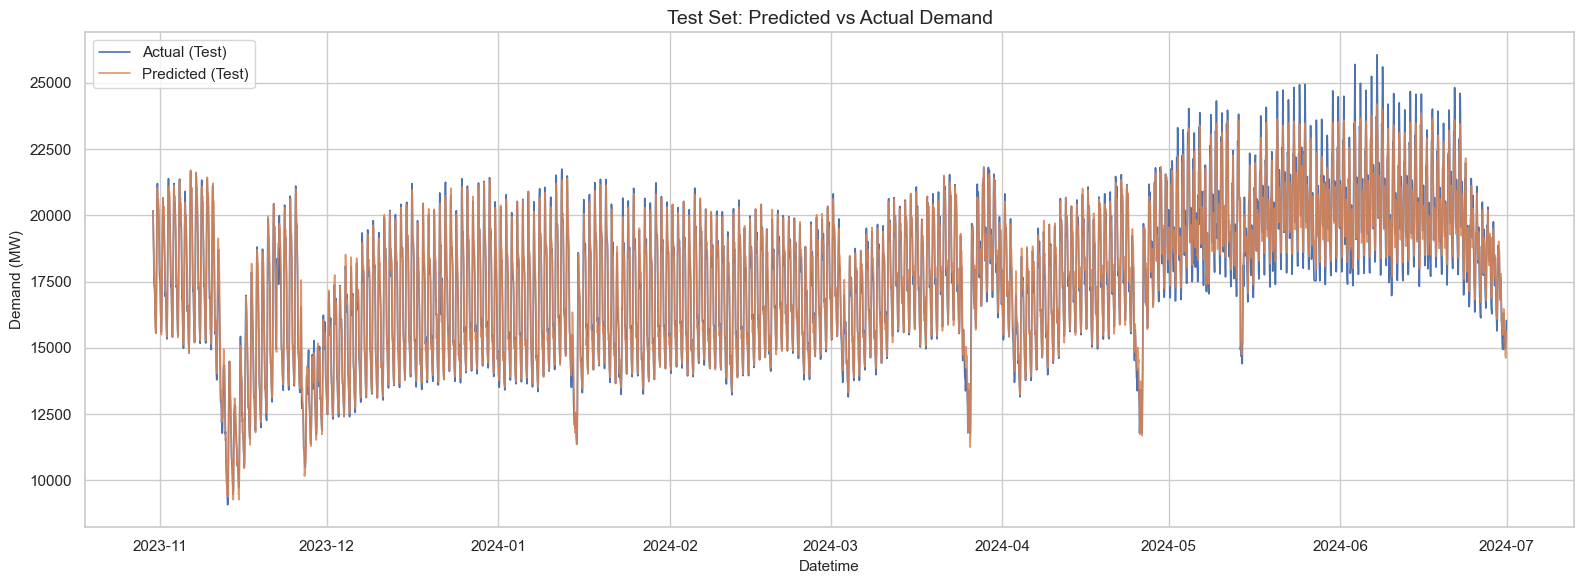

In [15]:
plt.figure(figsize=(16, 6))
plt.plot(test_pred_vs_actual['datetime'], test_pred_vs_actual['actual_mw'], label='Actual (Test)', linewidth=1.2)
plt.plot(test_pred_vs_actual['datetime'], test_pred_vs_actual['predicted_mw'], label='Predicted (Test)', linewidth=1.2, alpha=0.85)

plt.title('Test Set: Predicted vs Actual Demand')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Display all metrics for Train, Validation, and Test sets
metrics_df = pd.DataFrame([train_report, val_report, test_report], index=['Train', 'Validation', 'Test'])

display(metrics_df.style.format({
	'R2': '{:.6f}',
	'MAE': '{:.3f}',
	'RMSE': '{:.3f}',
	'MAPE_%': '{:.4f}',
	'Peak_MAPE_%': '{:.4f}',
	'Peak_Count': '{:d}',
}))

,R2,MAE,RMSE,MAPE_%,Peak_MAPE_%,Peak_Count
Train,0.985426,206.051,277.443,1.4545,1.0618,2738
Validation,0.977649,215.553,318.879,1.2885,0.6507,587
Test,0.970196,345.192,467.693,1.9531,2.1105,587


In [18]:
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
from pathlib import Path

model_to_export = globals().get('final_model')
if model_to_export is None:
    model_to_export = globals().get('calibration_model')
if model_to_export is None:
    raise NameError("No trained XGBoost model found. Run the model training cell first.")

n_features = int(getattr(model_to_export, 'n_features_in_', 0))
if n_features <= 0:
    raise ValueError("Could not determine input feature size from the trained model.")

# onnxmltools expects XGBoost feature names in f0, f1, ... format
booster = model_to_export.get_booster() if hasattr(model_to_export, "get_booster") else model_to_export
booster.feature_names = [f"f{i}" for i in range(n_features)]

onnx_model = convert_xgboost(
    booster,
    initial_types=[('input', FloatTensorType([None, n_features]))],
    target_opset=15,
)

models_dir = Path.cwd() / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

onnx_path = models_dir / 'xgboost_model.onnx'
with open(onnx_path, 'wb') as f:
    f.write(onnx_model.SerializeToString())

print(f'ONNX model saved to: {onnx_path}')

ONNX model saved to: d:\project course\models\xgboost_model.onnx
